In [37]:
what_were_covering = {1: "data (prepare and load)",
                     2: "build model",
                     3: "fitting the model to data (training)",
                     4: "making predictions and evaluting a model (inference)",
                     5: "saving and loading model",
                     6: "putting it all together"}
what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluting a model (inference)',
 5: 'saving and loading model',
 6: 'putting it all together'}

In [46]:
import torch
from torch import nn  #nn contains all pytorch's building blocks for neural networks
import matplotlib.pyplot as plt
torch.__version__

'2.6.0'

## 1. Data (preparing and loading)

Machine learning is a game of two parts:

Get data into a numerical representation.
Build a model to learn patterns in that numerical representation.

In [39]:
#linear regression formula to make a straight line with known parameter.
#create known parameters:
weight = 0.7
bias = 0.3

#Create
X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

## Splittind data into training and test sets

In [40]:
#Create a train/test split
train_size = int(0.8 * len(X))
train_size

40

In [41]:
X_train, y_train, X_test, y_test = X[:train_size], y[:train_size], X[train_size:], y[train_size:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

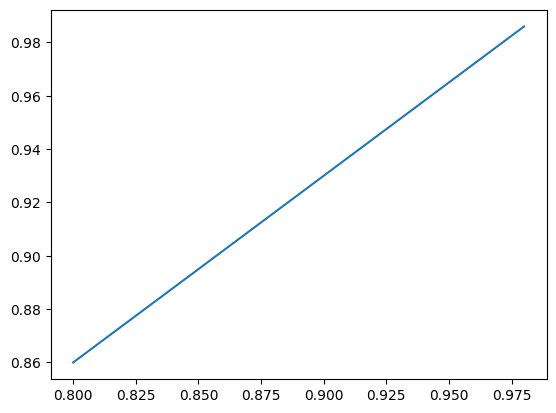

In [42]:
plt.plot(X_test, y_test)

## Visualize our data

In [43]:
def plot_predictions(train_data = X_train,
                    train_label = y_train,
                    test_data = X_test,
                    test_label = y_test,
                    predictions = None):

    #Plots training data, test data and compares predictions.
    plt.figure(figsize= (10,7)) #x ekseninin genişliği, y ekseninin genişliği

    #Plot traing data in green
    plt.scatter(train_data, train_label, c="g", s=4, label="Training Data")

    #Plot test data in blue
    plt.scatter(test_data, test_label, c="b", s=4, label="Test Data")

    #Plot the predictions if they exist
    if predictions:
        plt.scatter(x_test, predictions, c="r", s=4, label="Predicitons")

    plt.legend(prop={"size": 12}) #label kutusunun büyüklüğünü ayarlar.
    

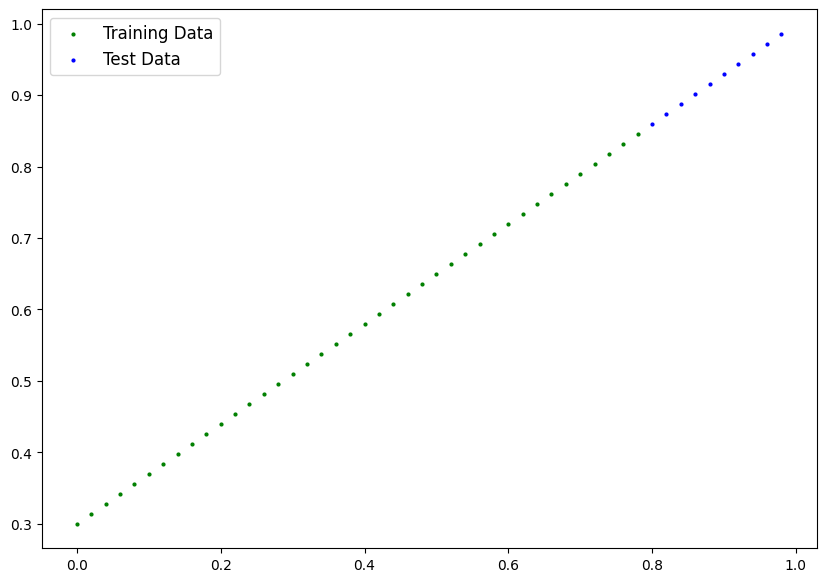

In [44]:
plot_predictions()

## 2. Build model

What our model does:
Start with random values (weight & bias)
Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

How does it do so?
Through two main algorithms:
1. Gradient descent
2. Backpropagation

In [49]:
# Create linear regression model class
class LinearRegressionModel(nn.Module):  # <- almost everything in PyTorch inherhits from nn.Module
    def __init__(self):
        super().__init__()  #üst sınıfın (nn.Module) başlangıç ayarlarını yapar.
        self.weights = nn.Parameter(torch.randn(1,  # <- start with a random weight and try to adjust it to the ideal weight
                                               requires_grad=True,  # <- can this parameter be updated via gradient descent?
                                               dtype=torch.float))  # <- PyTorch loves the datatype torch.float32
        
        self.bias = nn.Parameter(torch.randn(1,    # <- start with a random bias and try to adjust it to the ideal bias
                                            requires_grad=True,
                                            dtype=torch.float))

    # Forward method to define the computation in the model
    def forward(self, x:torch.tensor) -> torch.tensor:   # <- "x" is the input data
        return self.weights * x + self.bias              # this is the linear regression formula

## PyTorch model building essentials

torch.nn - contains all of the buildings for computational graphs (a neural network can be considered a computational graph)               
torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us             
torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward()                    
torch.optim - this where the optimizers in PyTorch live, they will help with gradient descent                              
def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation